<a href="https://colab.research.google.com/github/chethana-152005/Yuvaintern-Logistics-Data-Analyst-Intern/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_12561/1489616155.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic_Level', y='Time_taken_min', data=df, palette='Set2', order=['Low', 'Moderate', 'High', 'Severe'])


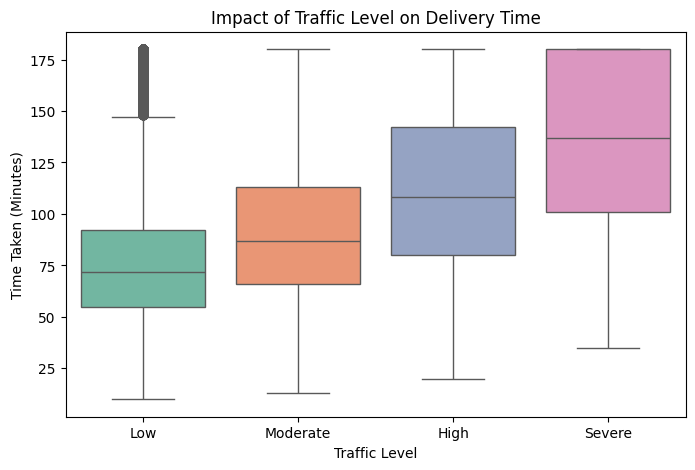

/tmp/ipykernel_12561/1489616155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Is_Weekend', y='Time_taken_min', data=df, palette='coolwarm')


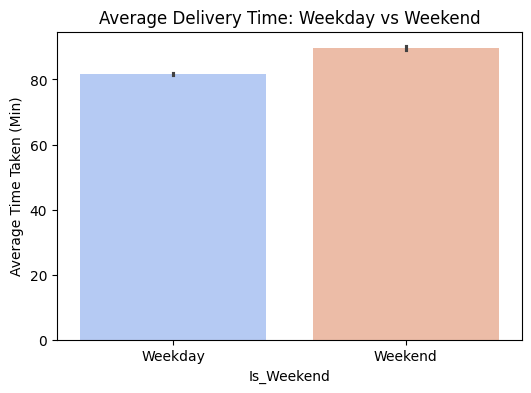

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Food_Delivery_Time_Prediction.csv')

# EDA: Visualizing the impact of Traffic Level on Delivery Time
plt.figure(figsize=(8, 5))
sns.boxplot(x='Traffic_Level', y='Time_taken_min', data=df, palette='Set2', order=['Low', 'Moderate', 'High', 'Severe'])
plt.title('Impact of Traffic Level on Delivery Time')
plt.xlabel('Traffic Level')
plt.ylabel('Time Taken (Minutes)')
plt.show()

# EDA: Delivery time difference between Weekends and Weekdays
plt.figure(figsize=(6, 4))
sns.barplot(x='Is_Weekend', y='Time_taken_min', data=df, palette='coolwarm')
plt.title('Average Delivery Time: Weekday vs Weekend')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel('Average Time Taken (Min)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Feature Engineering: Calculate estimated travel time in minutes
df['Estimated_Travel_Time_Min'] = (df['Road_Distance_km'] / df['Average_Speed_kmph']) * 60

# Select features for modeling
features = ['Order_Hour', 'Is_Weekend', 'Weather', 'Traffic_Level',
            'Rider_Experience_Years', 'Preparation_Time_Min', 'Road_Distance_km',
            'Estimated_Travel_Time_Min', 'Restaurant_Load']

X = df[features]
y = df['Time_taken_min']

# Convert categorical variables to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['Weather', 'Traffic_Level', 'Restaurant_Load'], drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
predictions = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")

# Feature Importance Analysis
importance = model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
print(feat_df.sort_values(by='Importance', ascending=False).head(5))

Model Evaluation Metrics:
Mean Absolute Error (MAE): 2.69 minutes
Root Mean Squared Error (RMSE): 3.44 minutes
                     Feature  Importance
5  Estimated_Travel_Time_Min    0.936259
3       Preparation_Time_Min    0.055970
4           Road_Distance_km    0.002209
2     Rider_Experience_Years    0.001587
0                 Order_Hour    0.001282
